# SNN Evaluation on Real-Time Data
In this notebook, we test the performance of trained SNNs on a real-time stream of data.
Based (or copied) from Mesquita's [repository](https://github.com/monkin77/snn-torch/blob/master/src/hfo/5_detection/hfo_evaluation.ipynb)

In [35]:

# Show current directory
import os
curr_dir = os.getcwd()
print(curr_dir)

from collections import deque

c:\Users\NCN\Documents\PedroFelix\LAVA_SNN_ripples\snnTorch


## Add Parent Directory to Path

In [36]:
import sys
parent_dir = os.path.abspath(os.path.join(curr_dir, os.pardir))
# Add the grandparent directory to the system path
# grandparent_dir = os.path.abspath(os.path.join(curr_dir, os.pardir, os.pardir))
sys.path.append(parent_dir)
print(sys.path)

['c:\\nrn\\lib\\python', 'c:\\Users\\NCN\\Miniconda3\\envs\\lava_snn_ripples\\python39.zip', 'c:\\Users\\NCN\\Miniconda3\\envs\\lava_snn_ripples\\DLLs', 'c:\\Users\\NCN\\Miniconda3\\envs\\lava_snn_ripples\\lib', 'c:\\Users\\NCN\\Miniconda3\\envs\\lava_snn_ripples', '', 'c:\\Users\\NCN\\Miniconda3\\envs\\lava_snn_ripples\\lib\\site-packages', 'c:\\Users\\NCN\\Miniconda3\\envs\\lava_snn_ripples\\lib\\site-packages\\win32', 'c:\\Users\\NCN\\Miniconda3\\envs\\lava_snn_ripples\\lib\\site-packages\\win32\\lib', 'c:\\Users\\NCN\\Miniconda3\\envs\\lava_snn_ripples\\lib\\site-packages\\Pythonwin', 'c:\\Users\\NCN\\Documents\\PedroFelix\\LAVA_SNN_ripples', 'c:\\Users\\NCN\\Documents\\PedroFelix\\LAVA_SNN_ripples']



## Check if Cuda is available


In [37]:
import torch
import numpy as np

# Check CUDA Installation
print(torch.cuda.is_available())

# Get the number of available GPUs
num_gpus = torch.cuda.device_count()
print(f"Number of GPUs: {num_gpus}")

# Get information about each GPU
for i in range(num_gpus):
    device_props = torch.cuda.get_device_properties(i)
    print(f"\nGPU {i}:")
    print(f"  Name: {device_props.name}")
    print(f"  Total memory: {device_props.total_memory / 1024**3:.2f} GB")
    print(f"  Multiprocessor count: {device_props.multi_processor_count}")
    print(f"  Major compute capability: {device_props.major}")
    print(f"  Minor compute capability: {device_props.minor}")

False
Number of GPUs: 0



## Define the Device that will be used to train the SNN


In [38]:


# Set the device to be used
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")     # torch.device("cpu") #

print("device: ", device)



device:  cpu



## Define Problem and Simulation Parameters


In [39]:
# ----- Simulation Time Parameters -----
dt = 1                         # Time between two timesteps (ms), a.k.a. virtual time step interval. (NOT ALIGNED WITH THE SAMPLING RATE OF THE INPUT DATA (2048 Hz)
init_offset = 0 # 900 # 33400      #   

In [40]:
# unit: timesteps (ms) - The time window after the GT annotation where the network should predict the burst (GT_time, GT_time + PRED_CAUSALITY_WINDOW)
# This is needed to give the network some extra time steps to increase the membrane potential and spike
RIPPLE_DETECTION_OFFSET = [18, 45, 31, 20]
PRED_CAUSALITY_WINDOW = int(5)     # Giving PRED_CAUSALITY_WINDOW ms for the network to update its inner state and spike  
# in timesteps (ms) - Max time from the Insertion Timing to the GT annotation

add_tolerance=True

TOLERANCE= RIPPLE_DETECTION_OFFSET[3] if add_tolerance else 0 # in timesteps (ms) - Tolerance for the prediction window, to account for the fact that the network might not be able to predict the burst exactly at the GT annotation time

MAX_DETECTION_OFFSET = int(RIPPLE_DETECTION_OFFSET[1]) * 1.5 + PRED_CAUSALITY_WINDOW + TOLERANCE # in timesteps (ms)

print(f"PRED_CAUSALITY_WINDOW: {PRED_CAUSALITY_WINDOW}")
print(f"MAX_DETECTION_OFFSET: {MAX_DETECTION_OFFSET} ms")

PRED_CAUSALITY_WINDOW: 5
MAX_DETECTION_OFFSET: 92.5 ms



## Read the Input Data and the Ground Truth


In [41]:
downsampled_fs="30000_1000"
data_dir=os.path.join(parent_dir,"extract_Nripples","train_pedro","dataset_up_down",str(downsampled_fs))

In [42]:
concat_data=np.load(os.path.join(data_dir,"concat_spikes.npy"),allow_pickle=True)
ripples_GT=np.load(os.path.join(data_dir,"concat_ripples.npy"),allow_pickle=True)

In [43]:
print("Number of UP spikes: ", np.sum(concat_data[:, 0]))
print("Number of DN spikes: ", np.sum(concat_data[:, 1]))

Number of UP spikes:  275624
Number of DN spikes:  277940



## Point of Situation

Right now, we have the following:

-  `concat_data` of shape (num_steps, 2) containing the UP and DN spikes.
- `ripples_GT` of shape (num_gt_events,2) containing the timestamps (beginning and end) of every ripple


In [44]:
#### CHOOSE A SEED FOR REPRODUCIBILITY
seed = 1
time_duration= 600 # in seconds, the duration of the test
window=np.arange(seed*time_duration*1000, (time_duration+seed*time_duration)*1000, 1) # 1000 ms window
cut_data=concat_data[window]
ripples_window=[]
print("Window:", window[0], window[-1])
for ripple in ripples_GT:
    if ripple[1] >= window[0] and ripple[0] <= window[-1]:
        ripples_window.append(ripple)
ripples_window=np.array(ripples_window)
cut_ripples_GT=ripples_window-window[0]  # Normalize the GT ripples to the window start time


Window: 600000 1199999


In [45]:
# Define the number of total timesteps
total_num_steps = cut_data.shape[0]
num_hfo_events = cut_ripples_GT.shape[0]
num_hfo_timesteps=np.sum(ripples_GT[:, 1] - ripples_GT[:, 0])
print(f"Number of HFO Events: {num_hfo_events}")
print(f"Total number of timesteps: {total_num_steps}")
print("Num of Ripple timesteps:", num_hfo_timesteps)

Number of HFO Events: 296
Total number of timesteps: 600000
Num of Ripple timesteps: 185776


In [46]:
# Transform ripples_GT into the time of onset...
ripples_start=cut_ripples_GT[:,0]-TOLERANCE
print("Ripples start: ", ripples_start[:10])

Ripples start:  [  672   873  1404  1833  7141  7412  7505  7613 14675 15223]


In [47]:
distance_ripples=ripples_start[1:] - ripples_start[:-1]
average_distance=np.mean(distance_ripples)
median_distance=np.median(distance_ripples)
min_distance=np.min(distance_ripples)
percentile_25=np.percentile(distance_ripples, 10)                            
print(f"Average distance between ripples: {average_distance} ms")
print(f"Median distance between ripples: {median_distance} ms")
print(f"Minimum distance between ripples: {min_distance} ms")
print(f"25th Percentile distance between ripples: {percentile_25} ms")


Average distance between ripples: 2016.1152542372881 ms
Median distance between ripples: 531.0 ms
Minimum distance between ripples: 69 ms
25th Percentile distance between ripples: 120.2 ms


In [48]:
# ------------------- Network Parameters -------------------
# We know that 2 relevant events do not occur within the confidence window of an HFO event, so we set the refractory period accordingly
refrac_period = 100 # floor(MAX_DETECTION_OFFSET / dt)   # Number of time-steps for the refractory period
print(f"Refractory Period: {refrac_period} steps")


Refractory Period: 100 steps


## Create the Dataset and Dataloader to user tensor-ready data


In [49]:
from torch.utils.data import TensorDataset, DataLoader

# Convert numpy arrays to PyTorch tensors and move them to the selected device
input_tensor = torch.tensor(cut_data,dtype=torch.float32).to(device)
gt_tensor=torch.tensor(ripples_start,dtype=torch.float32).to(device)
# gt_tensor = torch.from_numpy(ripples_start).to(device)
# gt_tensor = torch.from_numpy(ripples_start).to(device)


In [50]:
# Show the shape of the tensors
print("Input tensor shape: ", input_tensor.shape)
print("GT tensor shape: ", gt_tensor.shape)

Input tensor shape:  torch.Size([600000, 2])
GT tensor shape:  torch.Size([296])



## Define the SNN Architecture
Similar to what we trained before

In [51]:
import snntorch as snn
import torch.nn as nn
from snntorch import surrogate

# Global Parameters
v_thr = 1.0
placeholder_val = 0.5

# Define the surrogate gradient function to propagate spikes through the network
spike_grad = surrogate.fast_sigmoid()   # surrogate.atan()   

In [52]:


# Parameters for Dense Layers
inputDataDim = 2       # max_channel_idx - min_channel_idx + 1    # Number of input channels

input_to_hidden = (inputDataDim, 24) # 16 # TODO: Increase the size of this layer # (inputDataDim, 100) # (inputDataDim, 500)  # Number of neurons in the first Fully-Connected Layer

hiddenL2Dim = (input_to_hidden[1], input_to_hidden[1])  # Number of neurons in the Recurrent Fully-Connected Layer (L2)

hiddenL3Dim = (input_to_hidden[1], 16)  # Number of neurons in the Fully-Connected Layer (L3)

hiddenL4Dim = (hiddenL3Dim[1], input_to_hidden[1])  # Number of neurons in the Recurrent Fully-Connected Layer (L4)

hidden_to_out = (hiddenL3Dim[1], 1)  # Number of neurons in the Output Fully-Connected Layer
# In this case, we only need 1 output neuron -> Fires when HFO is detected



In [53]:
# Define Network
class Net(nn.Module):
    def __init__(self):
        super().__init__()

        # Initialize layers
        
        # Create a Linear Layer to serve input to LIF1
        self.fc_in = nn.Linear(input_to_hidden[0], input_to_hidden[1],
                bias=False,
                dtype=torch.float32     # Set the data type of the weights to float32
        )

        # TODO: Should the LIF neurons be able to get a negative membrane potential? I think so?
        self.lif1 = snn.Synaptic(
            alpha=torch.full(size=(input_to_hidden[1],), fill_value=placeholder_val), 
            beta=torch.full(size=(input_to_hidden[1],), fill_value=placeholder_val),
            threshold=v_thr,
            reset_mechanism="zero", reset_delay=False,
            # TODO: How to add Refractory Period?
            # init_hidden=True,   # enables the methods in snntorch.backprop to automatically clear the hidden states and detach them from the comp. graph
            spike_grad=spike_grad,
            learn_alpha=True,   # Learn the alpha parameter
            learn_beta=True,    # Learn the beta parameter
            learn_threshold=False,   # Learn the threshold parameter
            
        )      

        """ self.fc2 = nn.Linear(
            hiddenL2Dim[0], hiddenL2Dim[1],
            bias=False,
            dtype=torch.float32     # Set the data type of the weights to float32
        ) """

        self.fc3 = nn.Linear(
            hiddenL3Dim[0], hiddenL3Dim[1],
            bias=False,
            dtype=torch.float32     # Set the data type of the weights to float32
        )

        self.lif2 = snn.Synaptic(
            alpha=torch.full(size=(hiddenL3Dim[1],), fill_value=placeholder_val), 
            beta=torch.full(size=(hiddenL3Dim[1],), fill_value=placeholder_val),
            threshold=v_thr,
            reset_mechanism="zero", reset_delay=False,
            # TODO: How to add Refractory Period?
            # init_hidden=True,   # enables the methods in snntorch.backprop to automatically clear the hidden states and detach them from the comp. graph
            spike_grad=spike_grad,
            learn_alpha=True,   # Learn the alpha parameter
            learn_beta=True,    # Learn the beta parameter
            learn_threshold=False,   # Learn the threshold parameter
        )   

        """ self.fc4 = nn.Linear(
            hiddenL4Dim[0], hiddenL4Dim[1],
            bias=False,
            dtype=torch.float32     # Set the data type of the weights to float32
        ) """

        self.fc_out = nn.Linear(
            hidden_to_out[0], hidden_to_out[1],
            bias=False,
            dtype=torch.float32     # Set the data type of the weights to float32
        )

        self.lif_out = snn.Synaptic(
            alpha=placeholder_val, 
            beta=placeholder_val,
            threshold=v_thr,
            reset_mechanism="zero", reset_delay=False,
            # init_hidden=True,   # enables the methods in snntorch.backprop to automatically clear the hidden states and detach them from the comp. graph
            spike_grad=spike_grad,
            learn_alpha=True,   # Learn the alpha parameter
            learn_beta=True,    # Learn the beta parameter
            learn_threshold=False,   # Learn the threshold parameter
        )

        # Initialize the membrane potential of each LIF neuron
        self.syn1, self.mem1, self.spk1 = None, None, None
        self.syn2, self.mem2, self.spk2 = None, None, None
        self.syn_out, self.mem_out, self.spk_out = None, None, None

    """
    Function called during the forward pass of the network
    """
    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        '''
        Forward Pass of the Network (Single Step Update)

        Parameters:
        - x: input tensor. Shape: (batch_size, num_features)

        Returns:
        - spk_vals: tuple of tensors containing the spikes of the neurons. Shape: (batch_size, num_neurons)
        - mem_vals: tuple of tensors containing the membrane potentials of the neurons. Shape: (batch_size, num_neurons)
        - syn_vals: tuple of tensors containing the currents of the neurons. Shape: (batch_size, num_neurons)
        '''
        cur_batch_size, cur_num_channels = x.shape

        # --- Lazy State Initialization
        if self.mem1 is None:
            device = x.device   # Get the device of the input tensor

            # Initialize the membrane potential of each LIF neuron
            self.syn1, self.mem1 = self.lif1.reset_mem()
            self.syn2, self.mem2 = self.lif2.reset_mem()
            self.syn_out, self.mem_out = self.lif_out.reset_mem()

            # # Define small residual for spk1
            # spk1_factor = 0.01
            # self.spk1 = torch.rand(size=(cur_batch_size, input_to_hidden[1]), dtype=torch.float32, device=device) * spk1_factor
            # self.spk2 = torch.zeros(size=(cur_batch_size, hiddenL3Dim[1]), dtype=torch.float32, device=device) * spk1_factor
            # self.spk_out = torch.zeros(size=(cur_batch_size, hidden_to_out[1]), dtype=torch.float32, device=device)

        # 
        if len(x.shape) == 1:
            # If the input is 1D, it means we have only one feature (one channel)
            # Unsqueeze the input to add the num_features dimension
            x = x.unsqueeze(1)
            
        ############# State Update #############
        # Calculate Input Current for LIF1 from the Input Layer (FC1) Input -> LIF1
        cur_fc1 = self.fc_in(x) 
    
        # Calculate Input Current from Recurrent Layer (FC2) LIF1 -> LIF1
        # cur_fc2 = self.fc2(spk1)   # Connect LIF1 to itself using FC Layer 2 (Recurrent Layer)

        # Join the input currents for LIF1 (FC1 + FC2)
        cur1 = cur_fc1 # + cur_fc2  # TODO: Not feeding Recurent Layer to LIF1 for now

        # Feed the joined input current to LIF1
        self.spk1, self.syn1, self.mem1 = self.lif1(cur1, self.syn1, self.mem1)  # Feed input to LIF1

        # Calculate Input Current for LIF2 from LIF1 (FC3) LIF1 -> LIF2
        cur2 = self.fc3(self.spk1)   # Connect LIF1 to LIF2 using FC Layer 3
        # Feed the input current to LIF2 and get the spikes, synaptic currents and membrane potentials
        self.spk2, self.syn2, self.mem2 = self.lif2(cur2, self.syn2, self.mem2)  # Feed input to LIF2

        # Calculate Input Current for LIF_OUT from LIF2 (FC4) LIF2 -> LIF_OUT
        cur_out = self.fc_out(self.spk2)
        # Feed the input current to LIF_OUT and get the spikes, synaptic currents and membrane potentials
        self.spk_out, self.syn_out, self.mem_out = self.lif_out(cur_out, self.syn_out, self.mem_out)  # Feed input to LIF_OUT

        # Return the currents, membrane potentials and spikes of the current timestep
        syn_val = (self.syn1, self.syn2, self.syn_out)
        mem_vals = (self.mem1, self.mem2, self.mem_out)
        spk_vals = (self.spk1, self.spk2, self.spk_out)

        # TODO: Check if the dimensions are correct
        return (spk_vals, mem_vals, syn_val)


## Load the Trained Network


In [54]:
# Load the network onto CUDA if available
net = Net().to(device)
prefix="updnb4ds_100_7"
# Load the Trained Parameters from a file
net_filename = f"out/{prefix}_trained_net_loss.pth"  # trained_net_loss_penalty.pth
net.load_state_dict(torch.load(net_filename, map_location=device))

# Set the network to evaluation mode
net.eval()



Net(
  (fc_in): Linear(in_features=2, out_features=24, bias=False)
  (lif1): Synaptic()
  (fc3): Linear(in_features=24, out_features=16, bias=False)
  (lif2): Synaptic()
  (fc_out): Linear(in_features=16, out_features=1, bias=False)
  (lif_out): Synaptic()
)

## Show the Network Parameters

In [55]:


# Display the network architecture
total_params = 0    # Accumulator for the total params in the network
# Iterate through the layers of the network
for idx, (name, param) in enumerate(net.named_parameters()):
    # print("param: ", param)
    if param.shape == torch.Size([]):
        print(f"Scalar Param ({name}) | Shape={param.shape} | Value={param} \n")
    elif len(param.shape) == 1:
        print(f"Vector Param ({name}) | Shape={param.shape} | Value={param} \n")
    else:
        print(f"Tensor Param ({name}) | Shape={param.shape}. Total={param.numel()} Preview: {param[:8, :8]}\n")

    # Add the number of parameters in the layer to the total
    total_params += param.numel()

# Print the total number of parameters in the network
print(f"Total Parameters: {total_params}")



Tensor Param (fc_in.weight) | Shape=torch.Size([24, 2]). Total=48 Preview: tensor([[ 0.6103, -0.3327],
        [ 0.4580, -0.6386],
        [ 0.2715,  0.3227],
        [ 0.5790,  0.8790],
        [ 0.3127, -0.5822],
        [ 0.8198, -0.1536],
        [-0.4071,  0.5719],
        [ 0.6198,  0.5853]], grad_fn=<SliceBackward0>)

Vector Param (lif1.beta) | Shape=torch.Size([24]) | Value=Parameter containing:
tensor([0.7688, 0.4731, 0.6314, 0.3850, 0.4616, 0.1666, 0.1141, 0.4245, 0.6564,
        0.6586, 0.2663, 0.4501, 0.4911, 0.7719, 0.5043, 0.5991, 0.7169, 0.7351,
        0.5015, 0.2494, 0.6377, 0.8598, 0.3228, 0.4301], requires_grad=True) 

Vector Param (lif1.alpha) | Shape=torch.Size([24]) | Value=Parameter containing:
tensor([0.7091, 0.4598, 0.8417, 0.5808, 0.4822, 0.3080, 0.4516, 0.2803, 0.2588,
        0.6772, 0.4364, 0.7793, 0.3429, 0.6690, 0.5249, 0.3252, 0.5467, 0.4103,
        0.4576, 0.7018, 0.3906, 0.5908, 0.3361, 0.7876], requires_grad=True) 

Tensor Param (fc3.weight) | Shape=

## Feed the Data in Real-Time

In [56]:
# Store Confusion Matrix for Predictions
TP, TN, FP, FN = 0, 0, 0, 0

In [57]:


"""
Tensor to store the next timestep when each output neuron may spike (after the refractory period).
When a neuron spikes, it will be set to the current timestep + refractory period.
"""
lif_out_refrac_times = torch.full(size=(hidden_to_out[1],), fill_value=0.0, device=device)

print("lif_out_refrac_times: ", lif_out_refrac_times)



lif_out_refrac_times:  tensor([0.])


In [58]:
curr_gt_idx = 0 # Index of the current GT event
curr_gt = None  # Stores the current GT event (GT Insertion Timing)
'''
# Active GT Time-To-Live (TTL). This is a counter that decrements every timestep until it reaches 0.
If it reaches 0, it means the Network failed to predict the HFO within the GT tolerance window.
None -> No GT Event is active
'''
active_gts = deque()  # Queue of active GT events: each item is (gt_time, remaining_ttl)
out_spikes=[]
# Disable gradient calculation for inference
with torch.no_grad():
    for step in range(total_num_steps):
        # Get the current input (UP/DN spikes)
        curr_input = input_tensor[step]

        # Unsqueeze the input to add the num_batches dimension
        curr_input = curr_input.unsqueeze(0)
        # print(f"curr_input: {curr_input}")

        ADDED_FN = False    # Tracks if a False Negative was added in this timestep

        # # Check if a GT event leaves the detection window
        # if active_gt_ttl is not None and active_gt_ttl < 0:
        #     # GT Event Expired
        #     print(f"GT Event expired at timestep {step} with GT Insertion Timing: {curr_gt}")

        #     # Add a False Negative to the Confusion Matrix
        #     FN += 1
        #     # Set the TTL to None
        #     active_gt_ttl = None
        #     # Move to the next GT event
        #     curr_gt_idx += 1
        #     # Set ADDED_FN to True
        #     ADDED_FN = True

        # Check if a GT event enters the detection window
        if curr_gt_idx < num_hfo_events :
            curr_gt = int(gt_tensor[curr_gt_idx].item())  # Get the current GT Insertion Timing
            if curr_gt == step:
                # Check if a GT event was already active
                print(f"GT Event {curr_gt_idx} Insertion Timing: {curr_gt} at timestep {step}")
                active_gts.append((curr_gt, MAX_DETECTION_OFFSET))
                # if active_gt_ttl is not None:
                #     raise ValueError("[Error] Two GT events detected inside the Detection Window!")

                # GT Event starts at this timestep
                # print(f"GT Event starts at timestep {step} with GT Insertion Timing: {curr_gt}")
                
                # Set the TTL to the Maximum Detection Offset from the GT Insertion Timing
                # active_gt_ttl = MAX_DETECTION_OFFSET
                curr_gt_idx+=1
            
        # --------   State Update   --------
        spk, mem, syn = net(curr_input)

        # Get the spikes, membrane potentials and synaptic currents of the current timestep
        spk1, spk2, spk_out = spk
        mem1, mem2, mem_out = mem
        syn1, syn2, syn_out = syn
        # print(f"spk1: {spk1.shape} | spk2: {spk2.shape} | spk_out: {spk_out.shape}")
        # print(f"mem1: {mem1.shape} | mem2: {mem2.shape} | mem_out: {mem_out.shape}")
        # print(f"syn1: {syn1.shape} | syn2: {syn2.shape} | syn_out: {syn_out.shape}")

        if ADDED_FN:
            """
            If a FN was added -> GT event was not detected -> The problem formulation does not allow
            2 HFO events to be closer together than the confidence window, so we can skip this step
            """
            continue

        """ if torch.sum(spk2) > 0:
            # TODO: Remove this print statement
            print(f"LIF2 spiked at timestep {step} with spikes: {spk2}") """
        
        # Track which GTs remain active
        new_active_gts = deque()
        for gt_time, ttl in active_gts:
            if ttl < 0:
                FN += 1
                print(f"[FN] GT event at {gt_time} expired at timestep {step}")
            else:
                new_active_gts.append((gt_time, ttl - 1))
        active_gts = new_active_gts

        if torch.sum(spk_out) > 0:
            # Convert spk_out to int for bitwise operations (Squeeze the batch dimension)
            spk_out_int = spk_out.squeeze(0).int()
            out_spikes.append(step*dt)
            # Consider the refractory period of the output neurons
            REFRAC_STATE_MASK = lif_out_refrac_times > step * dt    # Check if each output neuron is in the refractory period
            # Bitwise AND between the spikes by the refractory state mask
            # Gets a mask of the neurons that spiked and are not in the refractory state
            valid_spk_out = torch.Tensor.bool(spk_out_int & (~REFRAC_STATE_MASK))

            # Check if any Valid Output Neuron spiked
            if torch.sum(valid_spk_out) > 0:
                # print(f"valid_spk_out: {valid_spk_out} | lif_out_refrac_times: {lif_out_refrac_times}")
                # Set the refractory period for the spiking output neurons
                lif_out_refrac_times[valid_spk_out] = float(step * dt + refrac_period)

                # If an Output Neuron spiked -> Predicted an HFO
                # Let's check if the predicted HFO is within the GT tolerance window
                if active_gts:
                    # The GT event is active -> Valid Prediction
                    gt_time, _ = active_gts.popleft()
                    TP += 1
                    print(f"[TP] Spike matched GT event at timestep {step} (GT: {gt_time})")
                else:
                    # The GT event is not active -> Invalid Prediction
                    FP += 1
                    print(f"[FP] Network detected HFO at timestep {step} without an active GT event")
            else:
                # No valid output neuron spiked -> No HFO Detected
                TN += 1     # Increment True Negatives (No HFO detected)
            
        else:
            # If the Output Neuron did not spike -> No HFO detected
            TN += 1     # Increment True Negatives (No HFO detected)


        if step % 100000 == 0:
            print(f"Processed step {step}/{total_num_steps} ({(step /total_num_steps) * 100:.2f}%)")



Processed step 0/600000 (0.00%)
[FP] Network detected HFO at timestep 240 without an active GT event
[FP] Network detected HFO at timestep 347 without an active GT event
GT Event 0 Insertion Timing: 672 at timestep 672
[TP] Spike matched GT event at timestep 693 (GT: 672)
GT Event 1 Insertion Timing: 873 at timestep 873
[TP] Spike matched GT event at timestep 929 (GT: 873)
[FP] Network detected HFO at timestep 1113 without an active GT event
[FP] Network detected HFO at timestep 1234 without an active GT event
GT Event 2 Insertion Timing: 1404 at timestep 1404
[TP] Spike matched GT event at timestep 1459 (GT: 1404)
[FP] Network detected HFO at timestep 1782 without an active GT event
GT Event 3 Insertion Timing: 1833 at timestep 1833
[TP] Spike matched GT event at timestep 1883 (GT: 1833)
GT Event 4 Insertion Timing: 7141 at timestep 7141
[TP] Spike matched GT event at timestep 7174 (GT: 7141)
GT Event 5 Insertion Timing: 7412 at timestep 7412
[TP] Spike matched GT event at timestep 74

In [59]:


# Show the Confusion Matrix
print(f"Confusion Matrix:")

# Print lines with same width
print(f"|TP: {TP} | FP: {FP}|\n|FN: {FN}  | TN: {TN}|")
if TP + FN != num_hfo_events:
    print("Mismatch in GT events")
    print(f"TP + FN: {TP + FN} | num_hfo_events: {num_hfo_events}")

Confusion Matrix:
|TP: 228 | FP: 311|
|FN: 68  | TN: 599461|


In [60]:


# Calculate the performance metrics
accuracy = round(((TP + TN) / (TP + TN + FP + FN)), 5)
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
false_positive_rate = FP / (FP + TN + 1e-10)


In [61]:


# Output the performance metrics
print(f"Accuracy (Right Prediction ): {accuracy:.4f}")
print(f"Recall (True Positive Rate): {recall:.4f}")
print(f"Specificity (True Negative Rate): {specificity:.4f}")
print(f"Precision (TP / (TP + FP)): {precision:.4f}")
print(f"F1 Score (Combines Precision & Recall): {f1_score:.4f}")
print(f"False Positive Rate (FP / (FP + TN)): {false_positive_rate:.4f}")
print(f"TP: {TP} | FP: {FP} | TN: {TN} | FN: {FN}")


Accuracy (Right Prediction ): 0.9994
Recall (True Positive Rate): 0.7703
Specificity (True Negative Rate): 0.9995
Precision (TP / (TP + FP)): 0.4230
F1 Score (Combines Precision & Recall): 0.5461
False Positive Rate (FP / (FP + TN)): 0.0005
TP: 228 | FP: 311 | TN: 599461 | FN: 68


In [62]:

total_predictions = TP + FP + TN + FN
print(f"Total Predictions: {total_predictions}")
print(f"Total Timesteps: {total_num_steps}")

Total Predictions: 600068
Total Timesteps: 600000


In [63]:
from utils.permutation_test import *
# Run the permutation test
actual_score,null_distribution,p_value=live_permutation_test(ripples_start,len(cut_data),out_spikes,MAX_DETECTION_OFFSET,refrac_period=refrac_period)
print(f"Actual Score: {actual_score:.4f} | Null Distribution Mean: {np.mean(null_distribution):.4f} | P-Value: {p_value:.4f}")

Actual Score: 0.5461 | Null Distribution Mean: 0.0582 | P-Value: 0.0000


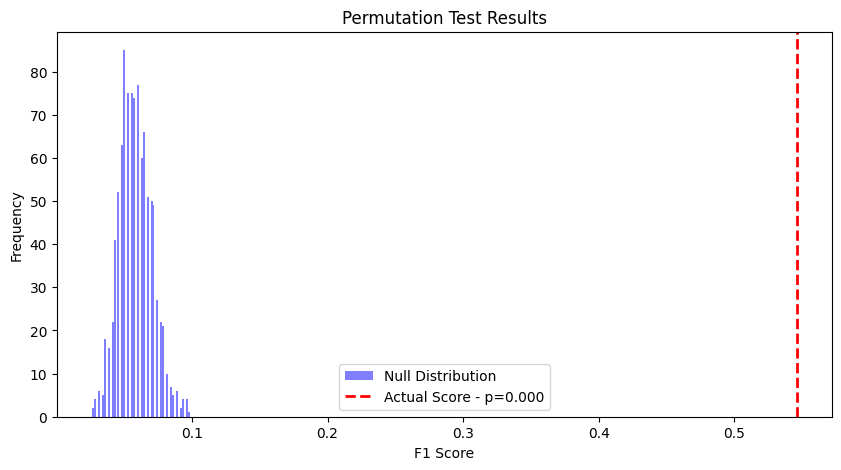

In [64]:
import matplotlib.pyplot as plt 
plt.figure(figsize=(10, 5), facecolor="w")
plt.hist(null_distribution, bins=50, alpha=0.5, label='Null Distribution', color='blue')
plt.axvline(actual_score, color='red', linestyle='dashed', linewidth=2, label=f'Actual Score - p={p_value:.3f}')
plt.title('Permutation Test Results')
plt.xlabel('F1 Score')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [65]:
import json

# Export the results to a JSON file
OUTPUT_FOLDER = f"eval/"
# create the output folder if it doesn't exist
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# Create a dictionary with the results
json_results = {
    "ripple_detection_offset": RIPPLE_DETECTION_OFFSET,
    "pred_causality_window": PRED_CAUSALITY_WINDOW,
    "max_detection_offset": MAX_DETECTION_OFFSET,
    "refractory_period_gt": refrac_period,
    "tolerance": TOLERANCE,
    "seed": seed,
    "time_duration": time_duration,
    "metrics": {
        "true_positive": TP,
        "false_positive": FP,
        "true_negative": TN,
        "false_negative": FN,
        "total_predictions": total_predictions,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1_score,
        "specificity": specificity,
        "false_positive_rate": false_positive_rate,
        "p_value": p_value,
        "null_distribution_mean": np.mean(null_distribution),
        "null_distribution_95th_percentile": np.percentile(null_distribution, 95),
    }
}

EXPORT_JSON_FILE = True
if EXPORT_JSON_FILE:
    json_file_name = f"{OUTPUT_FOLDER}/{prefix}_results_seed{seed}.json"
    with open(json_file_name, 'w') as f:
        json.dump(json_results, f)



In [66]:
out_spikes = np.array(out_spikes)
EXPORT_SPIKE_FILE = True
SPIKE_FOLDER= f"eval/spikes/"
if EXPORT_SPIKE_FILE:
    # create the output folder if it doesn't exist
    os.makedirs(SPIKE_FOLDER, exist_ok=True)
    spike_file_name = f"{SPIKE_FOLDER}/{prefix}_spikes_seed{seed}.npy"
    np.save(spike_file_name, out_spikes)